In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, TensorBoard, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.layers import LSTM, Dense, Conv1D, Flatten, Layer, GlobalAveragePooling1D, GlobalMaxPooling1D

2025-10-21 16:13:12.328237: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-21 16:13:13.266476: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-21 16:13:15.472807: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    TensorBoard(log_dir='./logs', histogram_freq=1, write_graph=True),
    ModelCheckpoint(filepath='main_cbam.keras', save_best_only=True),
]

In [ ]:
class CBAM1D(Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size

    def build(self, input_shape):
        channels = int(input_shape[-1])
        hidden = max(channels // self.ratio, 1)

        # Channel attention
        self.gap = GlobalAveragePooling1D()
        self.gmp = GlobalMaxPooling1D()
        self.fc1 = Dense(hidden, activation='relu', kernel_initializer='he_normal', use_bias=True)
        self.fc2 = Dense(channels, activation=None, kernel_initializer='he_normal', use_bias=True)

        # Spatial attention
        self.spatial_conv = Conv1D(filters=1, kernel_size=self.kernel_size,
                                   padding='same', activation='sigmoid',
                                   kernel_initializer='he_normal')
        super().build(input_shape)

    def call(self, inputs):
        # --- Channel Attention ---
        avg_pool = self.fc2(self.fc1(self.gap(inputs)))
        max_pool = self.fc2(self.fc1(self.gmp(inputs)))
        channel_attn = tf.nn.sigmoid(avg_pool + max_pool)
        channel_attn = tf.reshape(channel_attn, (-1, 1, tf.shape(inputs)[-1]))
        x = inputs * channel_attn

        # --- Spatial Attention ---
        avg_spatial = tf.reduce_mean(x, axis=-1, keepdims=True)
        max_spatial = tf.reduce_max(x, axis=-1, keepdims=True)
        spatial = tf.concat([avg_spatial, max_spatial], axis=-1)
        spatial_attn = self.spatial_conv(spatial)

        return x * spatial_attn

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"ratio": self.ratio, "kernel_size": self.kernel_size})
        return cfg


In [10]:
# Lire le CSV
csv_file = './currencies_data.csv'

In [11]:
# Lire le fichiers CSV dans un DataFrame pandas
df = pd.read_csv(csv_file, thousands=',')
df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,10/21/2025,3865.36,3977.70,3985.78,3842.69,505.95K,-2.87%
1,10/20/2025,3979.43,3982.68,4083.67,3909.40,549.92K,-0.08%
2,10/19/2025,3982.53,3889.19,4028.09,3844.52,463.11K,2.41%
3,10/18/2025,3888.87,3835.39,3927.37,3821.16,271.11K,1.49%
4,10/17/2025,3831.60,3894.48,3950.32,3679.90,880.38K,-1.61%


In [12]:
data = df['Price'].values.reshape(-1, 1)
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_data = scaler.fit_transform(data)

In [17]:
look_back = 30
generator = TimeseriesGenerator(normalized_data, normalized_data, length=look_back, batch_size=32)

In [18]:
model = Sequential([
    Conv1D(64, 3, activation='relu', input_shape=(look_back, 1)),
    CBAM1D(),
    LSTM(50),
    Dense(1)
])

In [19]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy'])
model.fit(generator, epochs=20, verbose=1, batch_size=32, callbacks=callbacks)

/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20


2025-10-21 16:17:17.541066: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91400


57/57 ━━━━━━━━━━━━━━━━━━━━ 23s 111ms/step - accuracy: 0.0011 - loss: 0.0500 - learning_rate: 0.0010
Epoch 2/20


/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)
/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate
  current = self.get_monitor_value(logs)
/home/oliwer/project/lstm-ipssi/.venv/lib/python3.10/site-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.0011 - loss: 0.0072 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 104ms/step - accuracy: 0.0011 - loss: 0.0043 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.0011 - loss: 0.0048 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 117ms/step - accuracy: 0.0011 - loss: 0.0033 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.0011 - loss: 0.0025 - learning_rate: 0.0010
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.0011 - loss: 0.0021 - learning_rate: 0.0010
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.0011 - loss: 0.0022 - learning_rate: 0.0010
Epoch 9/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.0011 - loss: 0.0018 - learning_rate: 0.0010
Epoch 10/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.0011 - loss: 0.0017 - learning_rate: 0.0010
Epoch 11/20
57/57 ━━━━━━

In [20]:
test_generator = TimeseriesGenerator(normalized_data, normalized_data, length=look_back, batch_size=1)
predictions = model.predict(test_generator)
predictions = scaler.inverse_transform(predictions)

1797/1797 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step


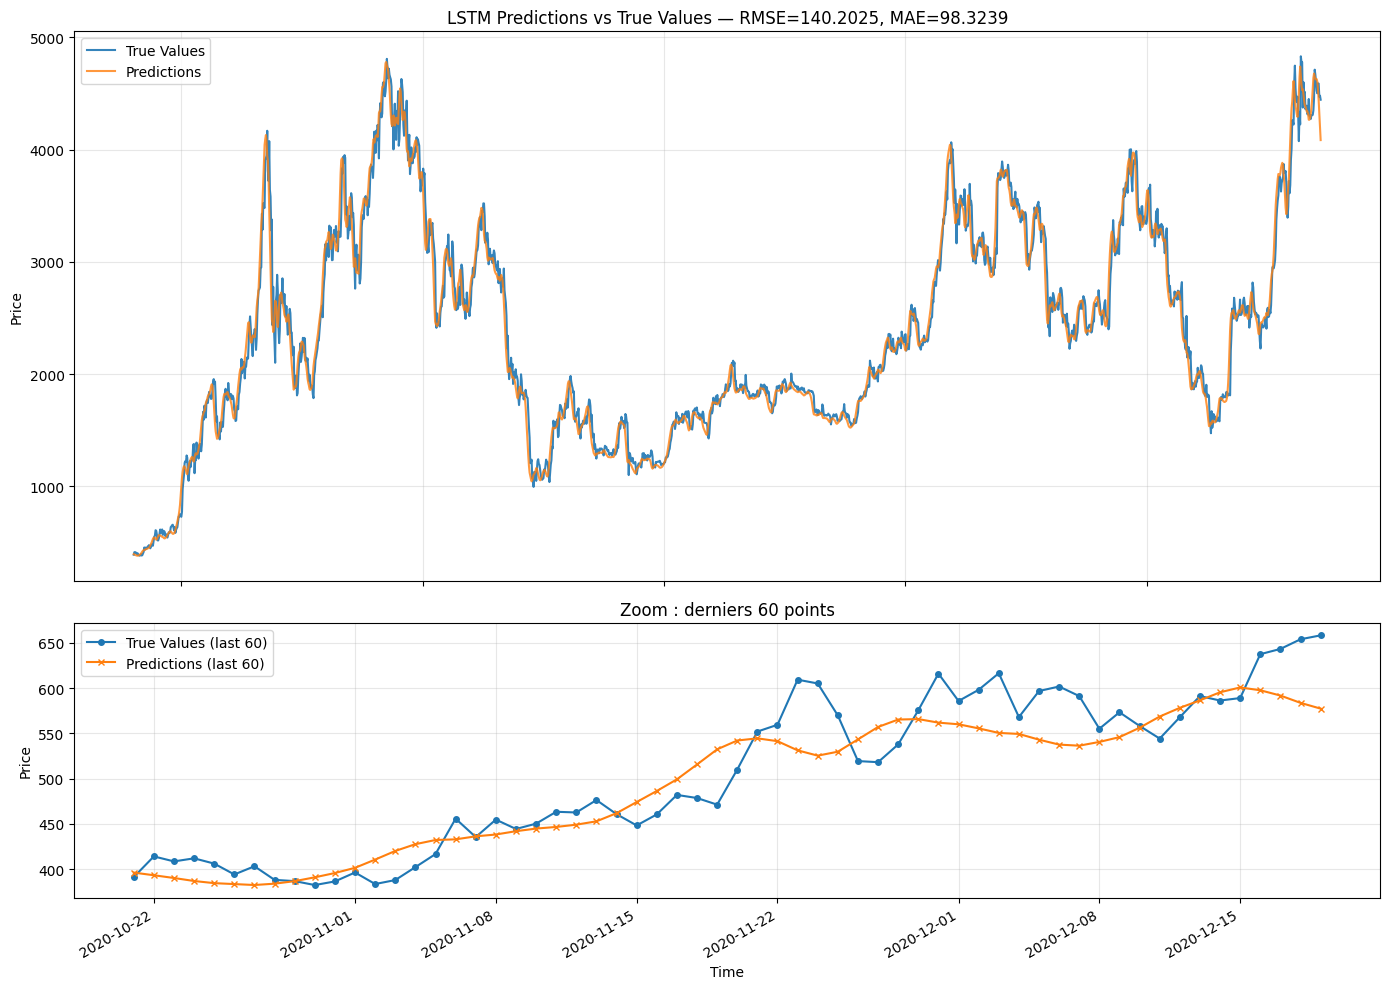

In [ ]:
import matplotlib.dates as mdates
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Préparer les séries
trues_values = data[look_back:].reshape(-1)         # True values (unidimensionnel)
preds = predictions.reshape(-1)                     # Predictions (unidimensionnel)

try:
    time_index = pd.to_datetime(df['Date'], errors='coerce')
    if time_index.isna().all():
        raise ValueError("Date column all NaT -> fallback to positional index")
    time_all = time_index.iloc[look_back:].to_numpy()   # numpy array (datetime64[ns]) ou object (Timestamp)
except Exception:
    time_all = np.arange(len(data))[look_back:]

rmse = np.sqrt(mean_squared_error(trues_values, preds))
mae = mean_absolute_error(trues_values, preds)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(time_all, trues_values, label='True Values', color='tab:blue', alpha=0.9)
ax1.plot(time_all, preds, label='Predictions', color='tab:orange', alpha=0.8)
ax1.set_title(f'LSTM Predictions vs True Values — RMSE={rmse:.4f}, MAE={mae:.4f}')
ax1.set_ylabel('Price')
ax1.grid(alpha=0.3)
ax1.legend(loc='upper left')

if hasattr(time_all, 'dtype') and np.issubdtype(time_all.dtype, np.datetime64):
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate(rotation=30)

last_n = 60
n = min(last_n, len(trues_values))
zoom_idx = slice(-n, None)

ax2.plot(time_all[zoom_idx], trues_values[zoom_idx], label=f'True Values (last {n})', color='tab:blue', marker='o', markersize=4)
ax2.plot(time_all[zoom_idx], preds[zoom_idx], label=f'Predictions (last {n})', color='tab:orange', marker='x', markersize=4)
ax2.set_title(f'Zoom : derniers {n} points')
ax2.set_xlabel('Time')
ax2.set_ylabel('Price')
ax2.grid(alpha=0.3)
ax2.legend(loc='upper left')

if hasattr(time_all, 'dtype') and np.issubdtype(time_all.dtype, np.datetime64):
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()